# **Surface Energy Balance and Energy Balance Closure**

How the energy that reaches the land surface is split among evaporation, heating the air, and heating the soil, and why measured fluxes rarely add up.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Write the surface energy balance and explain each term.
- Compute the evaporative fraction and Bowen ratio from flux-tower data and interpret their seasonal cycle.
- Quantify energy balance closure with the energy balance ratio and an ordinary least squares slope.
- Apply the Bowen-ratio closure correction and convert latent heat flux to evapotranspiration in mm per day.

**Before you start:** Basic Python (pandas, matplotlib). Notebook 02 builds on the same data.

## **The surface energy balance**

At the land surface, net radiation $R_n$ is the energy available. It is used to evaporate water (latent heat flux, $LE$),
to warm the air (sensible heat flux, $H$), and to warm the soil (ground heat flux, $G$):

$$ R_n = LE + H + G + \text{(storage and other small terms)} \qquad (1) $$

Two useful ratios describe how the available energy $R_n - G$ is partitioned:

- **Evaporative fraction:** $\;EF = \dfrac{LE}{LE + H}$ &nbsp;&nbsp; (fraction of turbulent energy that goes into evaporation)
- **Bowen ratio:** $\;\beta = \dfrac{H}{LE}$

Over a wet surface most energy goes into $LE$ ($EF \to 1$, $\beta \to 0$). Over a dry surface $H$ dominates.

## **The energy balance closure problem**

Eddy-covariance towers measure $H$ and $LE$ directly. When we compare $H + LE$ with $R_n - G$ at most sites, the turbulent
fluxes are **10 to 30% smaller** than the available energy. This is the *energy balance closure problem*. Two ways to quantify it:

- **Energy balance ratio:** $\;EBR = \dfrac{\sum (H + LE)}{\sum (R_n - G)}$
- **OLS slope** of $H + LE$ against $R_n - G$ (ideally 1, with intercept 0).

A common fix is the **Bowen-ratio correction** (Twine et al., 2000): assume the measured Bowen ratio is right and scale
$H$ and $LE$ so that they add up to $R_n - G$:

$$ LE_{corr} = \frac{R_n - G}{1 + \beta}, \qquad H_{corr} = \beta \, LE_{corr} \qquad (2) $$

This is the simplest correction. Newer methods (for example, physiology- or thermodynamics-based corrections) distribute
the residual differently, and the choice matters for evapotranspiration estimates.

**Site used in this tutorial:** US-Var (Vaira Ranch, California), an AmeriFlux grassland site with a Mediterranean climate: wet, mild winters and dry, hot summers. The daily file `daily_data_UA-Var_2000_2021.csv` contains gap-filled fluxes (LE, H, G), net radiation, meteorology, LAI, fPAR, GPP, and soil moisture (`theta_2`) for 2000-2021. Flux units are W m$^{-2}$ (daily means).

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime'])
df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'H_F_MDS': 'H', 'G_F_MDS': 'G', 'NETRAD': 'Rn', 'TA_F': 'TA',
                        'VPD_F': 'VPD', 'SW_IN_F': 'SW_IN', 'WS_F': 'WS', 'PA_F': 'PA'})
df[['Rn', 'LE', 'H', 'G', 'TA', 'VPD', 'theta_2']].describe().round(2)

,Rn,LE,H,G,TA,VPD,theta_2
count,8036.00,8036.00,8036.00,8036.00,8036.00,8036.00,7655.00
mean,87.18,23.68,45.54,0.92,16.08,10.79,0.17
std,59.11,25.02,41.22,8.14,6.75,8.89,0.10
min,-133.91,-2.43,-56.92,-69.00,0.95,0.00,0.02
25%,38.29,3.82,13.31,-4.59,10.53,3.57,0.09
50%,80.08,15.61,31.06,0.18,15.37,7.80,0.14
75%,137.58,33.10,81.91,6.62,21.58,16.52,0.26
max,230.48,126.29,141.65,29.78,36.24,45.97,0.47


## **Step 1: Look at the terms**

Plot a single year to see how the four terms move through the seasons.

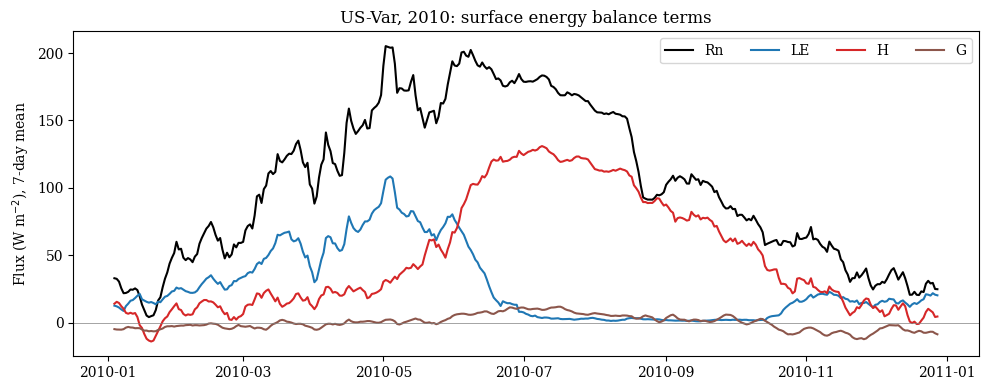

In [3]:
yr = df.loc['2010']
fig, ax = plt.subplots(figsize=(10, 4))
for col, c in zip(['Rn', 'LE', 'H', 'G'], ['k', 'tab:blue', 'tab:red', 'tab:brown']):
    ax.plot(yr.index, yr[col].rolling(7, center=True).mean(), label=col, color=c)
ax.set_ylabel('Flux (W m$^{-2}$), 7-day mean'); ax.set_title('US-Var, 2010: surface energy balance terms')
ax.axhline(0, color='grey', lw=0.5); ax.legend(ncol=4); plt.tight_layout()

**What to notice.** In winter and spring, when the grassland is green and the soil is wet, $LE$ is large. From June on,
the grass senesces and soil dries; $LE$ collapses and almost all available energy goes to $H$. This is the Mediterranean
climate signature: energy and water are out of phase.

## **Step 2: Evaporative fraction and Bowen ratio**

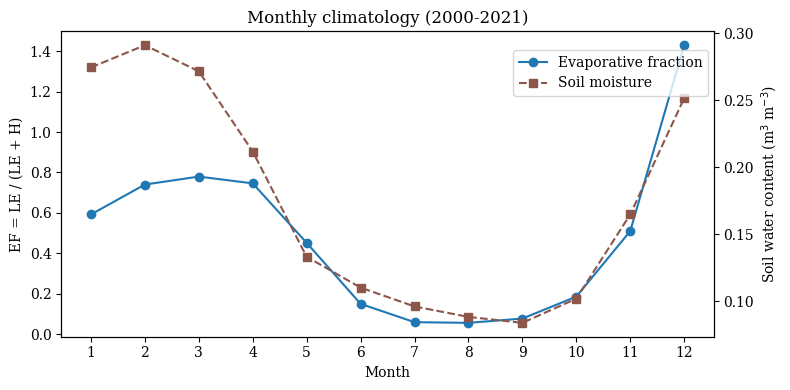

In [4]:
df['EF'] = df['LE'] / (df['LE'] + df['H'])
df['Bowen'] = df['H'] / df['LE']
# keep physically meaningful days: enough available energy and positive fluxes
ok = (df['Rn'] - df['G'] > 20) & (df['LE'] > 0) & (df['H'] > -20)
clim = df.loc[ok].groupby(df.loc[ok].index.month)[['EF', 'theta_2', 'LAI']].mean()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(clim.index, clim['EF'], 'o-', color='tab:blue', label='Evaporative fraction')
ax1.set_ylabel('EF = LE / (LE + H)'); ax1.set_xlabel('Month'); ax1.set_xticks(range(1, 13))
ax2 = ax1.twinx(); ax2.plot(clim.index, clim['theta_2'], 's--', color='tab:brown', label='Soil moisture')
ax2.set_ylabel('Soil water content (m$^3$ m$^{-3}$)')
ax1.set_title('Monthly climatology (2000-2021)'); fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88)); plt.tight_layout()

The evaporative fraction tracks soil moisture closely. When water is available, EF is high; as the root zone dries, EF drops
and the Bowen ratio climbs. This link between EF and soil moisture is the basis of several remote-sensing methods that
retrieve soil moisture from thermal observations.

## **Step 3: How well do the fluxes close?**

OLS slope = 0.71, intercept = 7.6 W m-2, R2 = 0.86
Energy balance ratio (EBR) = 0.79  ->  turbulent fluxes are 21% short of available energy


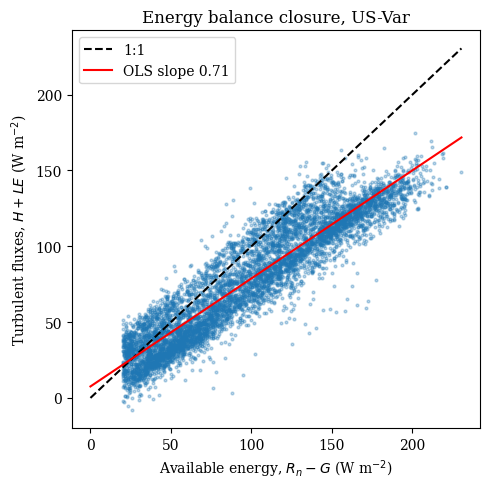

In [5]:
x = (df['Rn'] - df['G']).loc[ok]
y = (df['LE'] + df['H']).loc[ok]
slope, intercept = np.polyfit(x, y, 1)
ebr = y.sum() / x.sum()
r2 = np.corrcoef(x, y)[0, 1] ** 2
print(f'OLS slope = {slope:.2f}, intercept = {intercept:.1f} W m-2, R2 = {r2:.2f}')
print(f'Energy balance ratio (EBR) = {ebr:.2f}  ->  turbulent fluxes are {100*(1-ebr):.0f}% short of available energy')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, s=4, alpha=0.3)
lim = [0, max(x.max(), y.max())]
ax.plot(lim, lim, 'k--', label='1:1'); ax.plot(lim, np.polyval([slope, intercept], lim), 'r-', label=f'OLS slope {slope:.2f}')
ax.set_xlabel('Available energy, $R_n - G$ (W m$^{-2}$)'); ax.set_ylabel('Turbulent fluxes, $H + LE$ (W m$^{-2}$)')
ax.legend(); ax.set_title('Energy balance closure, US-Var'); plt.tight_layout()

## **Step 4: Does closure change with season or wetness?**

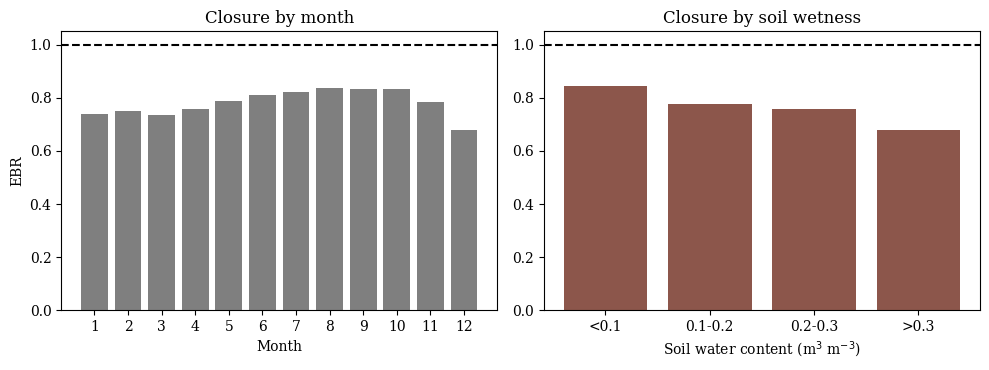

In [6]:
tmp = df.loc[ok, ['Rn', 'G', 'LE', 'H', 'theta_2']].copy()
tmp['month'] = tmp.index.month
ebr_m = tmp.groupby('month').apply(lambda g: (g['LE'] + g['H']).sum() / (g['Rn'] - g['G']).sum())
tmp['wet'] = pd.cut(tmp['theta_2'], [0, 0.1, 0.2, 0.3, 0.6], labels=['<0.1', '0.1-0.2', '0.2-0.3', '>0.3'])
ebr_w = tmp.groupby('wet', observed=True).apply(lambda g: (g['LE'] + g['H']).sum() / (g['Rn'] - g['G']).sum())

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
axs[0].bar(ebr_m.index, ebr_m.values, color='tab:grey'); axs[0].axhline(1, color='k', ls='--')
axs[0].set_xlabel('Month'); axs[0].set_ylabel('EBR'); axs[0].set_title('Closure by month'); axs[0].set_xticks(range(1, 13))
axs[1].bar(ebr_w.index.astype(str), ebr_w.values, color='tab:brown'); axs[1].axhline(1, color='k', ls='--')
axs[1].set_xlabel('Soil water content (m$^3$ m$^{-3}$)'); axs[1].set_title('Closure by soil wetness'); plt.tight_layout()

Closure is not a constant. It changes with season and surface state, which is why a single correction factor applied to
all days can bias evapotranspiration estimates. This is an active research question.

One more check that every data user should make: closure **by year**. Instruments get replaced, and the record shows it.

Date
2000    0.98
2001    0.88
2002    0.89
2003    0.91
2004    1.01
2005    1.02
2006    1.11
2007    1.02
2008    0.97
2009    0.72
2010    0.74
2011    0.68
2012    0.69
2013    0.71
2014    0.67
2015    0.69
2016    0.75
2017    0.73
2018    0.72
2019    0.70
2020    0.71
2021    0.71


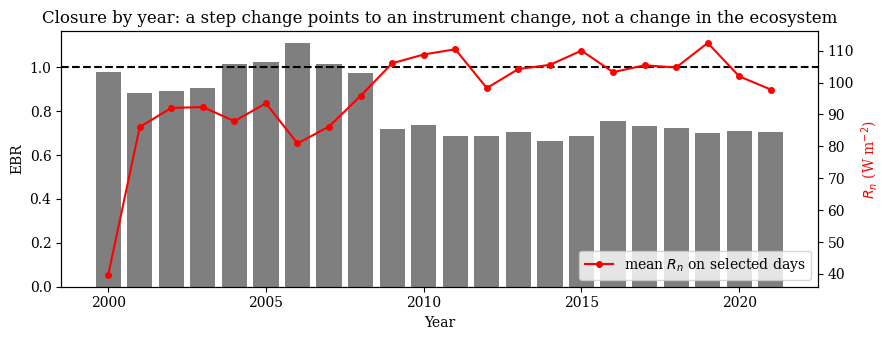

In [7]:
ebr_y = tmp.groupby(tmp.index.year).apply(lambda g: (g['LE'] + g['H']).sum() / (g['Rn'] - g['G']).sum())
rn_y = df.loc[ok, 'Rn'].groupby(df.loc[ok].index.year).mean()
fig, ax1 = plt.subplots(figsize=(9, 3.5))
ax1.bar(ebr_y.index, ebr_y.values, color='tab:grey'); ax1.axhline(1, color='k', ls='--'); ax1.set_ylabel('EBR'); ax1.set_xlabel('Year')
ax2 = ax1.twinx(); ax2.plot(rn_y.index, rn_y.values, 'ro-', ms=4, label='mean $R_n$ on selected days'); ax2.set_ylabel('$R_n$ (W m$^{-2}$)', color='r'); ax2.legend(loc='lower right')
ax1.set_title('Closure by year: a step change points to an instrument change, not a change in the ecosystem'); plt.tight_layout()
print(ebr_y.round(2).to_string())

At US-Var the energy balance ratio drops from about 1.0 to about 0.7 between 2008 and 2009, at the same time as the
measured net radiation jumps. The ecosystem did not change; the radiometer did. Any analysis that spans this break
(trends in closure, long-term corrected ET) has to account for it. Always look at the record before trusting the average.

## **Step 5: Bowen-ratio correction and conversion to evapotranspiration**

To convert latent heat flux (W m$^{-2}$, daily mean) to evapotranspiration (mm day$^{-1}$):

$$ ET = \frac{LE \times 86400}{\lambda \, \rho_w} \approx \frac{LE \times 86400}{2.45 \times 10^{6} \times 1000} \times 1000 = LE \times 0.0353 $$

where $\lambda$ is the latent heat of vaporization (2.45 MJ kg$^{-1}$ at 20 $^\circ$C; it decreases slightly with temperature).

      ET_mm  ET_corr_mm
Date                   
2000  304.0       296.0
2001  291.0       278.0
2002  274.0       271.0
2003  329.0       332.0
2004  267.0       231.0
2005  385.0       328.0
2006  315.0       251.0
2007  273.0       253.0
2008  234.0       208.0
2009  322.0       461.0

Mean annual ET: measured 303 mm, Bowen-ratio corrected 371 mm


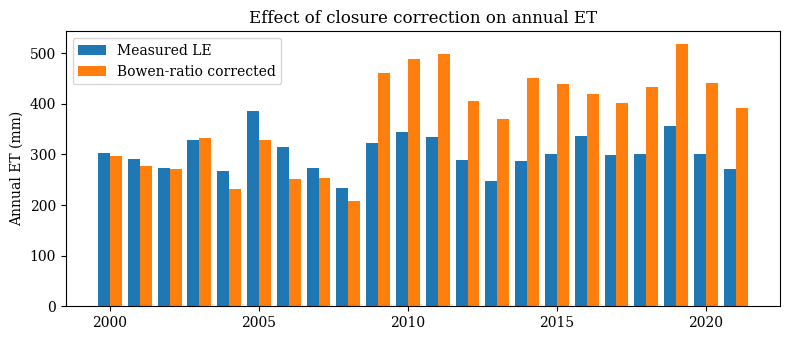

In [8]:
def latent_heat(T):        # MJ kg-1, T in degC
    return 2.501 - 0.002361 * T

# the correction is unstable when the Bowen ratio approaches -1 (H and LE cancel), so require beta > -0.5
stable = ok & (df['Bowen'] > -0.5)
df['LE_corr'] = np.where(stable, (df['Rn'] - df['G']) / (1 + df['Bowen']), np.nan)
df['ET_mm'] = df['LE'] * 86400 / (latent_heat(df['TA']) * 1e6)          # mm/day
df['ET_corr_mm'] = df['LE_corr'] * 86400 / (latent_heat(df['TA']) * 1e6)

annual = df[['ET_mm', 'ET_corr_mm']].resample('YE').sum()
annual.index = annual.index.year
print(annual.round(0).head(10))
print(f"\nMean annual ET: measured {annual['ET_mm'].mean():.0f} mm, Bowen-ratio corrected {annual['ET_corr_mm'].mean():.0f} mm")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(annual.index - 0.2, annual['ET_mm'], width=0.4, label='Measured LE')
ax.bar(annual.index + 0.2, annual['ET_corr_mm'], width=0.4, label='Bowen-ratio corrected')
ax.set_ylabel('Annual ET (mm)'); ax.legend(); ax.set_title('Effect of closure correction on annual ET'); plt.tight_layout()

The correction adds roughly the closure gap to annual ET. Whether that is right depends on where the missing energy
actually went, which is why several correction methods exist and give different answers.

## **Exercises**

**Exercise 1.** Compute the energy balance ratio separately for the wet season (November to April) and the dry season (May to October). Which season closes better? Suggest one physical reason.

**Exercise 2.** Repeat the OLS closure analysis using only days with $R_n - G > 100$ W m$^{-2}$. Does the slope change? Why might closure depend on the magnitude of available energy?

**Exercise 3.** The Bowen-ratio correction assumes $\beta$ is measured correctly. Write the correction that instead assigns the entire residual to $LE$ and compare annual ET from the two corrections.

**Exercise 4.** Using `Sample_data.csv` (a different site, one year), compute EF, the Bowen ratio and the EBR, and compare with US-Var.

## **References**

- Twine, T. E., et al. (2000). Correcting eddy-covariance flux underestimates over a grassland. *Agricultural and Forest Meteorology*, 103, 279-300.
- Wilson, K., et al. (2002). Energy balance closure at FLUXNET sites. *Agricultural and Forest Meteorology*, 113, 223-243.
- Mauder, M., Foken, T., & Cuxart, J. (2020). Surface-energy-balance closure over land: a review. *Boundary-Layer Meteorology*, 177, 395-426.
- Raghav, P., & Kumar, M. (2026). PULSE: A novel potential underlying water use efficiency-based method for latent heat and surface energy imbalance correction. *Water Resources Research*.